In [21]:
!pip install faiss-cpu pandas matplotlib

In [22]:
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import platform

SEED = 20260918
np.random.seed(SEED)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Faiss:", faiss.__version__)

Python: 3.13.15
NumPy: 2.1.3
Faiss: 1.15.1


In [23]:
N = 10000
D = 32
N_CLUSTERS = 20

rng = np.random.default_rng(SEED)

centres = rng.normal(0, 5, size=(N_CLUSTERS, D)).astype("float32")

cluster_ids = rng.integers(0, N_CLUSTERS, size=N)

vectors = (
    centres[cluster_ids] +
    rng.normal(0, 1, size=(N, D))
).astype("float32")

In [24]:
order = rng.permutation(N)

metadata_rank = np.empty(N, dtype=np.int32)
metadata_rank[order] = np.arange(N)

In [25]:
def get_filter_mask(selectivity):
    n_pass = int(N * selectivity)
    return metadata_rank < n_pass

In [26]:
for s in [0.01, 0.10, 0.50, 1.00]:
    mask = get_filter_mask(s)
    print(f"{int(s*100)}% selectivity: {mask.sum()} vectors")

1% selectivity: 100 vectors
10% selectivity: 1000 vectors
50% selectivity: 5000 vectors
100% selectivity: 10000 vectors


In [27]:
print("Dataset shape:", vectors.shape)
print("Data type:", vectors.dtype)
print("Number of vectors:", N)
print("Dimensions:", D)
print("Clusters:", N_CLUSTERS)

Dataset shape: (10000, 32)
Data type: float32
Number of vectors: 10000
Dimensions: 32
Clusters: 20


In [28]:
def generate_queries(n):
    cluster_ids_q = rng.integers(0, N_CLUSTERS, size=n)

    queries = (
        centres[cluster_ids_q] +
        rng.normal(0, 1, size=(n, D))
    ).astype("float32")

    return queries


calibration_queries = generate_queries(20)
test_queries = generate_queries(60)

print("Calibration queries:", calibration_queries.shape)
print("Test queries:", test_queries.shape)
print("Data type:", test_queries.dtype)

Calibration queries: (20, 32)
Test queries: (60, 32)
Data type: float32


In [29]:
K = 10

def exact_ground_truth(query, selectivity):
    mask = get_filter_mask(selectivity)

    eligible_ids = np.where(mask)[0]
    eligible_vectors = vectors[eligible_ids]

    distances = np.sum(
        (eligible_vectors - query) ** 2,
        axis=1
    )

    top_indices = np.argsort(distances)[:K]

    return eligible_ids[top_indices]

In [30]:
q = test_queries[0]

for s in [0.01, 0.10, 0.50, 1.00]:
    gt = exact_ground_truth(q, s)

    print(
        f"{int(s*100)}% selectivity:",
        len(gt),
        "ground-truth neighbours"
    )

1% selectivity: 10 ground-truth neighbours
10% selectivity: 10 ground-truth neighbours
50% selectivity: 10 ground-truth neighbours
100% selectivity: 10 ground-truth neighbours


In [31]:
def filter_first(query, selectivity):
    start = time.perf_counter()

    result = exact_ground_truth(query, selectivity)

    latency_ms = (time.perf_counter() - start) * 1000

    return result, latency_ms

In [32]:
def hnsw_vector_first(
    query,
    selectivity,
    ef_search=64,
    candidates=500
):
    start = time.perf_counter()

    index.hnsw.efSearch = ef_search

    _, ids = index.search(
        query.reshape(1, -1),
        candidates
    )

    ids = ids[0]

    # Remove invalid IDs if any
    ids = ids[ids >= 0]

    # Apply metadata filter
    mask = get_filter_mask(selectivity)

    valid_ids = ids[mask[ids]]

    # Exact reranking of surviving candidates
    if len(valid_ids) == 0:
        result = np.array([], dtype=np.int64)

    else:
        distances = np.sum(
            (vectors[valid_ids] - query) ** 2,
            axis=1
        )

        order = np.argsort(distances)[:K]

        result = valid_ids[order]

    latency_ms = (
        time.perf_counter() - start
    ) * 1000

    return result, latency_ms

In [33]:
def recall_at_k(result, ground_truth):
    if len(ground_truth) == 0:
        return np.nan

    common = np.intersect1d(
        result,
        ground_truth
    )

    return len(common) / len(ground_truth)

In [34]:
M = 16

index = faiss.IndexHNSWFlat(D, M)
index.hnsw.efConstruction = 100

start = time.perf_counter()

index.add(vectors)

build_time = time.perf_counter() - start

print("HNSW vectors:", index.ntotal)
print("M:", M)
print("efConstruction:", index.hnsw.efConstruction)
print("Build time:", build_time, "seconds")

HNSW vectors: 10000
M: 16
efConstruction: 100
Build time: 1.297177630999954 seconds


In [35]:
q = test_queries[0]

for s in [0.01, 0.10, 0.50, 1.00]:

    ground_truth = exact_ground_truth(q, s)

    result, latency = hnsw_vector_first(
        q,
        s,
        ef_search=64,
        candidates=500
    )

    recall = recall_at_k(
        result,
        ground_truth
    )

    print(
        f"{int(s*100)}% selectivity:",
        f"returned={len(result)},",
        f"recall={recall:.3f},",
        f"latency={latency:.4f} ms"
    )

1% selectivity: returned=4, recall=0.400, latency=1.0431 ms
10% selectivity: returned=10, recall=1.000, latency=2.8158 ms
50% selectivity: returned=10, recall=1.000, latency=0.5073 ms
100% selectivity: returned=10, recall=1.000, latency=0.6838 ms


In [36]:
q = test_queries[0]

for s in [0.01, 0.10, 0.50, 1.00]:
    result, latency = filter_first(q, s)

    print(
        f"{int(s*100)}% selectivity:",
        f"{len(result)} results,",
        f"{latency:.4f} ms"
    )

1% selectivity: 10 results, 0.8403 ms
10% selectivity: 10 results, 0.5539 ms
50% selectivity: 10 results, 2.1795 ms
100% selectivity: 10 results, 4.1573 ms


In [37]:
q = test_queries[0]

for s in [0.01, 0.10, 0.50, 1.00]:
    result, latency = filter_first(q, s)

    print(
        f"{int(s*100)}% selectivity:",
        f"{len(result)} results,",
        f"{latency:.4f} ms"
    )

1% selectivity: 10 results, 0.5528 ms
10% selectivity: 10 results, 1.1074 ms
50% selectivity: 10 results, 1.5731 ms
100% selectivity: 10 results, 1.7040 ms


In [38]:
HNSW_PLANS = {
    "HNSW-low": {
        "ef_search": 32,
        "candidates": 100
    },

    "HNSW-medium": {
        "ef_search": 64,
        "candidates": 500
    },

    "HNSW-high": {
        "ef_search": 128,
        "candidates": 2000
    }
}

print(HNSW_PLANS)

{'HNSW-low': {'ef_search': 32, 'candidates': 100}, 'HNSW-medium': {'ef_search': 64, 'candidates': 500}, 'HNSW-high': {'ef_search': 128, 'candidates': 2000}}


In [39]:
def run_plan(query, selectivity, plan_name):

    if plan_name == "Exact-filter-first":
        return filter_first(query, selectivity)

    config = HNSW_PLANS[plan_name]

    return hnsw_vector_first(
        query,
        selectivity,
        ef_search=config["ef_search"],
        candidates=config["candidates"]
    )

In [40]:
q = test_queries[0]
s = 0.01

ground_truth = exact_ground_truth(q, s)

plan_names = [
    "Exact-filter-first",
    "HNSW-low",
    "HNSW-medium",
    "HNSW-high"
]

for plan in plan_names:

    result, latency = run_plan(
        q,
        s,
        plan
    )

    recall = recall_at_k(
        result,
        ground_truth
    )

    print(
        f"{plan:20s}",
        f"returned={len(result):2d}",
        f"recall={recall:.3f}",
        f"latency={latency:.4f} ms"
    )

Exact-filter-first   returned=10 recall=1.000 latency=0.6759 ms
HNSW-low             returned= 3 recall=0.300 latency=1.0366 ms
HNSW-medium          returned= 4 recall=0.400 latency=0.4418 ms
HNSW-high            returned= 6 recall=0.600 latency=0.6285 ms


In [41]:
# Warm-up before timing experiments
for i in range(5):
    _ = index.search(
        calibration_queries[i].reshape(1, -1),
        100
    )

print("Warm-up complete.")

Warm-up complete.


In [42]:
selectivities = [0.01, 0.10, 0.50, 1.00]

plan_names = [
    "Exact-filter-first",
    "HNSW-low",
    "HNSW-medium",
    "HNSW-high"
]

calibration_records = []

plan_rng = np.random.default_rng(SEED + 100)

for query_id, query in enumerate(calibration_queries):

    for s in selectivities:

        # Exact ground truth used only to measure recall
        ground_truth = exact_ground_truth(
            query,
            s
        )

        # Shuffle execution order to reduce ordering bias
        shuffled_plans = plan_names.copy()
        plan_rng.shuffle(shuffled_plans)

        for plan in shuffled_plans:

            result, latency = run_plan(
                query,
                s,
                plan
            )

            recall = recall_at_k(
                result,
                ground_truth
            )

            calibration_records.append({
                "query_id": query_id,
                "selectivity": s,
                "plan": plan,
                "returned": len(result),
                "recall": recall,
                "latency_ms": latency
            })


calibration_df = pd.DataFrame(
    calibration_records
)

print("Calibration executions:",
      len(calibration_df))

calibration_df.head()

Calibration executions: 320


,query_id,selectivity,plan,returned,recall,latency_ms
0,0,0.01,Exact-filter-first,10,1.0,0.131087
1,0,0.01,HNSW-medium,5,0.5,0.496374
2,0,0.01,HNSW-low,2,0.2,0.733889
3,0,0.01,HNSW-high,5,0.5,0.730778
4,0,0.10,HNSW-high,10,1.0,0.762388


In [43]:
calibration_summary = (
    calibration_df
    .groupby(
        ["selectivity", "plan"],
        as_index=False
    )
    .agg(
        mean_recall=("recall", "mean"),
        mean_latency_ms=("latency_ms", "mean"),
        p50_latency_ms=(
            "latency_ms",
            lambda x: np.percentile(x, 50)
        ),
        p95_latency_ms=(
            "latency_ms",
            lambda x: np.percentile(x, 95)
        ),
        mean_returned=("returned", "mean")
    )
)

calibration_summary

,selectivity,plan,mean_recall,mean_latency_ms,p50_latency_ms,p95_latency_ms,mean_returned
0,0.01,Exact-filter-first,1.000,0.071624,0.056203,0.118463,10.00
1,0.01,HNSW-high,0.520,0.476787,0.427048,0.673904,5.25
2,0.01,HNSW-low,0.105,0.186389,0.151305,0.243166,1.05
3,0.01,HNSW-medium,0.440,0.280096,0.240719,0.505972,4.40
4,0.10,Exact-filter-first,1.000,0.285237,0.253752,0.431587,10.00
5,0.10,HNSW-high,1.000,0.493138,0.453139,0.741127,10.00
6,0.10,HNSW-low,0.895,0.175224,0.148776,0.289453,9.10
7,0.10,HNSW-medium,0.995,0.289939,0.266165,0.348238,10.00
8,0.50,Exact-filter-first,1.000,0.968035,0.932110,1.228664,10.00
9,0.50,HNSW-high,1.000,0.506306,0.479353,0.712740,10.00


In [44]:
calibration_df.to_csv(
    "calibration_records.csv",
    index=False
)

calibration_summary.to_csv(
    "calibration_summary.csv",
    index=False
)

print("Saved:")
print("- calibration_records.csv")
print("- calibration_summary.csv")

Saved:
- calibration_records.csv
- calibration_summary.csv


In [45]:
RECALL_TARGET = 0.95

prediction_table = calibration_summary[
    [
        "selectivity",
        "plan",
        "mean_recall",
        "mean_latency_ms"
    ]
].copy()


def choose_no_feedback_plan(
    selectivity,
    recall_target=RECALL_TARGET
):

    rows = prediction_table[
        np.isclose(
            prediction_table["selectivity"],
            selectivity
        )
    ]

    # Keep only plans predicted to meet recall target
    feasible = rows[
        rows["mean_recall"] >= recall_target
    ]

    # Choose lowest predicted latency
    if len(feasible) > 0:
        chosen = feasible.sort_values(
            "mean_latency_ms"
        ).iloc[0]

        return chosen["plan"]

    # Safe fallback
    return "Exact-filter-first"

In [46]:
print("Recall target:", RECALL_TARGET)

for s in [0.01, 0.10, 0.50, 1.00]:

    chosen = choose_no_feedback_plan(s)

    print(
        f"{int(s*100):3d}% selectivity"
        f" -> {chosen}"
    )

Recall target: 0.95
  1% selectivity -> Exact-filter-first
 10% selectivity -> Exact-filter-first
 50% selectivity -> HNSW-low
100% selectivity -> HNSW-low


In [47]:
FIXED_PLAN = "HNSW-medium"

print("Fixed baseline:", FIXED_PLAN)
print(HNSW_PLANS[FIXED_PLAN])

Fixed baseline: HNSW-medium
{'ef_search': 64, 'candidates': 500}


In [48]:
ALPHA = 0.20

adaptive_table = prediction_table.copy()

adaptive_table

,selectivity,plan,mean_recall,mean_latency_ms
0,0.01,Exact-filter-first,1.000,0.071624
1,0.01,HNSW-high,0.520,0.476787
2,0.01,HNSW-low,0.105,0.186389
3,0.01,HNSW-medium,0.440,0.280096
4,0.10,Exact-filter-first,1.000,0.285237
5,0.10,HNSW-high,1.000,0.493138
6,0.10,HNSW-low,0.895,0.175224
7,0.10,HNSW-medium,0.995,0.289939
8,0.50,Exact-filter-first,1.000,0.968035
9,0.50,HNSW-high,1.000,0.506306


In [49]:
def choose_adaptive_plan(
    selectivity,
    recall_target=RECALL_TARGET
):

    rows = adaptive_table[
        np.isclose(
            adaptive_table["selectivity"],
            selectivity
        )
    ]

    feasible = rows[
        rows["mean_recall"] >= recall_target
    ]

    if len(feasible) > 0:

        chosen = feasible.sort_values(
            "mean_latency_ms"
        ).iloc[0]

        return chosen["plan"]

    return "Exact-filter-first"

In [50]:
def update_adaptive_latency(
    selectivity,
    plan,
    observed_latency,
    alpha=ALPHA
):

    mask = (
        np.isclose(
            adaptive_table["selectivity"],
            selectivity
        )
        &
        (adaptive_table["plan"] == plan)
    )

    old_value = adaptive_table.loc[
        mask,
        "mean_latency_ms"
    ].iloc[0]

    new_value = (
        (1 - alpha) * old_value
        +
        alpha * observed_latency
    )

    adaptive_table.loc[
        mask,
        "mean_latency_ms"
    ] = new_value

In [51]:
def update_adaptive_recall(
    selectivity,
    plan,
    observed_recall,
    alpha=ALPHA
):

    mask = (
        np.isclose(
            adaptive_table["selectivity"],
            selectivity
        )
        &
        (adaptive_table["plan"] == plan)
    )

    old_value = adaptive_table.loc[
        mask,
        "mean_recall"
    ].iloc[0]

    new_value = (
        (1 - alpha) * old_value
        +
        alpha * observed_recall
    )

    adaptive_table.loc[
        mask,
        "mean_recall"
    ] = new_value

In [52]:
def reset_adaptive_table():
    global adaptive_table

    adaptive_table = prediction_table.copy()

In [53]:
reset_adaptive_table()

print("Adaptive table reset.")

Adaptive table reset.


In [54]:
test_records = []

for s in selectivities:

    # Start adaptive policy from original calibration table
    reset_adaptive_table()

    for query_id, query in enumerate(test_queries):

        # Ground truth for evaluation only
        # This time is NOT included in normal query latency.
        ground_truth = exact_ground_truth(
            query,
            s
        )

        # ---------------------------------
        # 1. FIXED HNSW
        # ---------------------------------

        start = time.perf_counter()

        fixed_result, _ = run_plan(
            query,
            s,
            FIXED_PLAN
        )

        fixed_total_ms = (
            time.perf_counter() - start
        ) * 1000

        fixed_recall = recall_at_k(
            fixed_result,
            ground_truth
        )

        test_records.append({
            "query_id": query_id,
            "selectivity": s,
            "policy": "Fixed HNSW",
            "plan": FIXED_PLAN,
            "recall": fixed_recall,
            "latency_ms": fixed_total_ms,
            "audit": False
        })


        # ---------------------------------
        # 2. NO FEEDBACK
        # ---------------------------------

        start = time.perf_counter()

        no_feedback_plan = (
            choose_no_feedback_plan(s)
        )

        nf_result, _ = run_plan(
            query,
            s,
            no_feedback_plan
        )

        nf_total_ms = (
            time.perf_counter() - start
        ) * 1000

        nf_recall = recall_at_k(
            nf_result,
            ground_truth
        )

        test_records.append({
            "query_id": query_id,
            "selectivity": s,
            "policy": "No feedback",
            "plan": no_feedback_plan,
            "recall": nf_recall,
            "latency_ms": nf_total_ms,
            "audit": False
        })


        # ---------------------------------
        # 3. ADAPTIVE
        # ---------------------------------

        start = time.perf_counter()

        adaptive_plan = (
            choose_adaptive_plan(s)
        )

        adaptive_result, _ = run_plan(
            query,
            s,
            adaptive_plan
        )

        adaptive_recall = recall_at_k(
            adaptive_result,
            ground_truth
        )

        # Update latency prediction
        elapsed_before_update = (
            time.perf_counter() - start
        ) * 1000

        update_adaptive_latency(
            s,
            adaptive_plan,
            elapsed_before_update
        )

        # Exact audit every 10th query
        audited = (
            (query_id + 1) % 10 == 0
        )

        if audited:

            audit_ground_truth = (
                exact_ground_truth(
                    query,
                    s
                )
            )

            audit_recall = recall_at_k(
                adaptive_result,
                audit_ground_truth
            )

            update_adaptive_recall(
                s,
                adaptive_plan,
                audit_recall
            )

        adaptive_total_ms = (
            time.perf_counter() - start
        ) * 1000

        test_records.append({
            "query_id": query_id,
            "selectivity": s,
            "policy": "Adaptive",
            "plan": adaptive_plan,
            "recall": adaptive_recall,
            "latency_ms": adaptive_total_ms,
            "audit": audited
        })


test_df = pd.DataFrame(test_records)

print(
    "Final test executions:",
    len(test_df)
)

test_df.head()

Final test executions: 720


,query_id,selectivity,policy,plan,recall,latency_ms,audit
0,0,0.01,Fixed HNSW,HNSW-medium,0.4,0.526856,False
1,0,0.01,No feedback,Exact-filter-first,1.0,2.122519,False
2,0,0.01,Adaptive,Exact-filter-first,1.0,5.246898,False
3,1,0.01,Fixed HNSW,HNSW-medium,0.4,0.459426,False
4,1,0.01,No feedback,Exact-filter-first,1.0,1.587962,False


In [55]:
final_summary = (
    test_df
    .groupby(
        ["selectivity", "policy"],
        as_index=False
    )
    .agg(
        mean_recall=(
            "recall",
            "mean"
        ),

        mean_latency_ms=(
            "latency_ms",
            "mean"
        ),

        p50_latency_ms=(
            "latency_ms",
            lambda x:
            np.percentile(x, 50)
        ),

        p95_latency_ms=(
            "latency_ms",
            lambda x:
            np.percentile(x, 95)
        )
    )
)

final_summary

,selectivity,policy,mean_recall,mean_latency_ms,p50_latency_ms,p95_latency_ms
0,0.01,Adaptive,1.000000,3.735546,3.037952,5.401149
1,0.01,Fixed HNSW,0.395000,0.498669,0.456133,0.567775
2,0.01,No feedback,1.000000,1.815421,1.436839,3.554939
3,0.10,Adaptive,1.000000,2.635190,2.289596,3.866909
4,0.10,Fixed HNSW,0.991667,0.418632,0.346170,0.531050
5,0.10,No feedback,1.000000,1.316170,1.195570,1.920066
6,0.50,Adaptive,0.986667,3.511292,3.320395,6.341847
7,0.50,Fixed HNSW,0.995000,0.556952,0.521676,0.622591
8,0.50,No feedback,0.975000,1.625296,1.696326,1.981715
9,1.00,Adaptive,0.995000,2.911908,2.213276,5.057580


In [56]:
test_df.to_csv(
    "test_results.csv",
    index=False
)

final_summary.to_csv(
    "final_summary.csv",
    index=False
)

print("Saved:")
print("- test_results.csv")
print("- final_summary.csv")

Saved:
- test_results.csv
- final_summary.csv


In [57]:
print("Fixed plan:", FIXED_PLAN)
print("Recall target:", RECALL_TARGET)
print("Alpha:", ALPHA)
print("Test queries:", len(test_queries))
print("Selectivities:", selectivities)

print("\nNo-feedback choices:")
for s in selectivities:
    print(
        f"{int(s*100):3d}% ->",
        choose_no_feedback_plan(s)
    )

Fixed plan: HNSW-medium
Recall target: 0.95
Alpha: 0.2
Test queries: 60
Selectivities: [0.01, 0.1, 0.5, 1.0]

No-feedback choices:
  1% -> Exact-filter-first
 10% -> Exact-filter-first
 50% -> HNSW-low
100% -> HNSW-low


In [58]:
for i in range(10):
    q = test_queries[i % len(test_queries)]

    _ = run_plan(
        q,
        0.10,
        "HNSW-medium"
    )

print("Final warm-up complete.")

Final warm-up complete.


In [59]:
REPETITIONS = 3

POLICIES = [
    "Fixed HNSW",
    "No feedback",
    "Adaptive"
]

final_records_v2 = []

order_rng = np.random.default_rng(SEED + 2000)


for rep in range(REPETITIONS):

    print(f"Starting repetition {rep + 1}/{REPETITIONS}")

    for s in selectivities:

        # Every repetition and selectivity starts
        # from the original calibration table
        reset_adaptive_table()

        for query_id, query in enumerate(test_queries):

            # ------------------------------------------------
            # Ground truth for evaluation ONLY.
            # Its cost is excluded from policy latency.
            # ------------------------------------------------

            ground_truth = exact_ground_truth(
                query,
                s
            )

            # Randomise policy execution order
            policy_order = POLICIES.copy()
            order_rng.shuffle(policy_order)

            for order_position, policy in enumerate(policy_order):

                planning_ms = 0.0
                search_ms = 0.0
                update_ms = 0.0
                audit_ms = 0.0
                audited = False


                # ============================================
                # FIXED HNSW
                # ============================================

                if policy == "Fixed HNSW":

                    chosen_plan = FIXED_PLAN

                    result, search_ms = run_plan(
                        query,
                        s,
                        chosen_plan
                    )

                    recall = recall_at_k(
                        result,
                        ground_truth
                    )


                # ============================================
                # NO FEEDBACK
                # ============================================

                elif policy == "No feedback":

                    planning_start = time.perf_counter()

                    chosen_plan = (
                        choose_no_feedback_plan(s)
                    )

                    planning_ms = (
                        time.perf_counter()
                        - planning_start
                    ) * 1000


                    result, search_ms = run_plan(
                        query,
                        s,
                        chosen_plan
                    )

                    recall = recall_at_k(
                        result,
                        ground_truth
                    )


                # ============================================
                # ADAPTIVE
                # ============================================

                elif policy == "Adaptive":

                    # -----------------------
                    # Planner
                    # -----------------------

                    planning_start = time.perf_counter()

                    chosen_plan = (
                        choose_adaptive_plan(s)
                    )

                    planning_ms = (
                        time.perf_counter()
                        - planning_start
                    ) * 1000


                    # -----------------------
                    # Search execution
                    # -----------------------

                    result, search_ms = run_plan(
                        query,
                        s,
                        chosen_plan
                    )


                    # Evaluation recall:
                    # not included in latency
                    recall = recall_at_k(
                        result,
                        ground_truth
                    )


                    # -----------------------
                    # Latency feedback update
                    # -----------------------

                    update_start = time.perf_counter()

                    # Important:
                    # calibration table contains execution
                    # latency, so update it using search_ms
                    update_adaptive_latency(
                        s,
                        chosen_plan,
                        search_ms
                    )

                    update_ms = (
                        time.perf_counter()
                        - update_start
                    ) * 1000


                    # -----------------------
                    # Exact recall audit
                    # every 10th query
                    # -----------------------

                    audited = (
                        (query_id + 1) % 10 == 0
                    )

                    if audited:

                        audit_start = time.perf_counter()

                        # Recompute exact ground truth
                        # to model synchronous audit cost
                        audit_ground_truth = (
                            exact_ground_truth(
                                query,
                                s
                            )
                        )

                        audit_recall = recall_at_k(
                            result,
                            audit_ground_truth
                        )

                        update_adaptive_recall(
                            s,
                            chosen_plan,
                            audit_recall
                        )

                        audit_ms = (
                            time.perf_counter()
                            - audit_start
                        ) * 1000


                # ============================================
                # End-to-end latency
                # ============================================

                total_latency_ms = (
                    planning_ms
                    + search_ms
                    + update_ms
                    + audit_ms
                )


                final_records_v2.append({
                    "repetition": rep + 1,
                    "query_id": query_id,
                    "selectivity": s,
                    "policy": policy,
                    "order_position": order_position + 1,
                    "plan": chosen_plan,
                    "returned": len(result),
                    "recall": recall,
                    "planning_ms": planning_ms,
                    "search_ms": search_ms,
                    "update_ms": update_ms,
                    "audit_ms": audit_ms,
                    "latency_ms": total_latency_ms,
                    "audit": audited
                })


final_test_v2 = pd.DataFrame(
    final_records_v2
)

print("\nFinal executions:",
      len(final_test_v2))

final_test_v2.head()

Starting repetition 1/3
Starting repetition 2/3
Starting repetition 3/3

Final executions: 2160


,repetition,query_id,selectivity,policy,order_position,plan,returned,recall,planning_ms,search_ms,update_ms,audit_ms,latency_ms,audit
0,1,0,0.01,Adaptive,1,Exact-filter-first,10,1.0,3.944186,0.165039,6.059102,0.0,10.168327,False
1,1,0,0.01,No feedback,2,Exact-filter-first,10,1.0,4.808831,0.201213,0.000000,0.0,5.010044,False
2,1,0,0.01,Fixed HNSW,3,HNSW-medium,4,0.4,0.000000,0.480645,0.000000,0.0,0.480645,False
3,1,1,0.01,Adaptive,1,Exact-filter-first,10,1.0,3.827897,0.153844,3.963916,0.0,7.945657,False
4,1,1,0.01,Fixed HNSW,2,HNSW-medium,4,0.4,0.000000,2.513549,0.000000,0.0,2.513549,False


In [60]:
execution_check = (
    final_test_v2
    .groupby(
        ["selectivity", "policy"]
    )
    .size()
    .reset_index(name="executions")
)

execution_check

,selectivity,policy,executions
0,0.01,Adaptive,180
1,0.01,Fixed HNSW,180
2,0.01,No feedback,180
3,0.10,Adaptive,180
4,0.10,Fixed HNSW,180
5,0.10,No feedback,180
6,0.50,Adaptive,180
7,0.50,Fixed HNSW,180
8,0.50,No feedback,180
9,1.00,Adaptive,180


In [61]:
final_summary_v2 = (
    final_test_v2
    .groupby(
        ["selectivity", "policy"],
        as_index=False
    )
    .agg(
        executions=(
            "latency_ms",
            "size"
        ),

        mean_recall=(
            "recall",
            "mean"
        ),

        mean_latency_ms=(
            "latency_ms",
            "mean"
        ),

        p50_latency_ms=(
            "latency_ms",
            lambda x:
            np.percentile(x, 50)
        ),

        p95_latency_ms=(
            "latency_ms",
            lambda x:
            np.percentile(x, 95)
        )
    )
)

final_summary_v2

,selectivity,policy,executions,mean_recall,mean_latency_ms,p50_latency_ms,p95_latency_ms
0,0.01,Adaptive,180,1.000000,4.702863,3.206073,10.173802
1,0.01,Fixed HNSW,180,0.395000,0.666212,0.452701,2.487969
2,0.01,No feedback,180,1.000000,2.238650,1.498006,5.168936
3,0.10,Adaptive,180,0.996111,6.214551,4.963743,12.804813
4,0.10,Fixed HNSW,180,0.991667,0.697692,0.467759,2.524208
5,0.10,No feedback,180,1.000000,3.142038,1.986027,6.267824
6,0.50,Adaptive,180,0.988333,6.735831,3.894295,17.230406
7,0.50,Fixed HNSW,180,0.995000,0.864302,0.534678,2.673209
8,0.50,No feedback,180,0.975000,3.116794,1.892628,8.116801
9,1.00,Adaptive,180,0.995556,9.875656,7.561676,24.957028


In [62]:
adaptive_only = final_test_v2[
    final_test_v2["policy"] == "Adaptive"
].copy()


adaptive_overhead = (
    adaptive_only
    .groupby(
        "selectivity",
        as_index=False
    )
    .agg(
        mean_planning_ms=(
            "planning_ms",
            "mean"
        ),

        mean_update_ms=(
            "update_ms",
            "mean"
        ),

        amortised_audit_ms=(
            "audit_ms",
            "mean"
        ),

        mean_total_ms=(
            "latency_ms",
            "mean"
        )
    )
)


adaptive_overhead[
    "mean_adaptation_overhead_ms"
] = (
    adaptive_overhead[
        "mean_planning_ms"
    ]
    +
    adaptive_overhead[
        "mean_update_ms"
    ]
    +
    adaptive_overhead[
        "amortised_audit_ms"
    ]
)


adaptive_overhead

,selectivity,mean_planning_ms,mean_update_ms,amortised_audit_ms,mean_total_ms,mean_adaptation_overhead_ms
0,0.01,2.030429,2.233606,0.255989,4.702863,4.520023
1,0.10,2.443117,2.547381,0.350901,6.214551,5.341399
2,0.50,2.647148,2.673288,0.510581,6.735831,5.831016
3,1.00,3.828703,3.854812,0.745694,9.875656,8.429210


In [63]:
audit_events = adaptive_only[
    adaptive_only["audit"] == True
]

audit_event_summary = (
    audit_events
    .groupby(
        "selectivity",
        as_index=False
    )
    .agg(
        number_of_audits=(
            "audit_ms",
            "size"
        ),

        mean_audit_event_ms=(
            "audit_ms",
            "mean"
        ),

        p95_audit_event_ms=(
            "audit_ms",
            lambda x:
            np.percentile(x, 95)
        )
    )
)

audit_event_summary

,selectivity,number_of_audits,mean_audit_event_ms,p95_audit_event_ms
0,0.01,18,2.559886,6.197821
1,0.10,18,3.509012,7.234091
2,0.50,18,5.105807,10.209068
3,1.00,18,7.456945,15.029867


In [64]:
plan_counts_v2 = (
    final_test_v2
    .groupby(
        [
            "selectivity",
            "policy",
            "plan"
        ]
    )
    .size()
    .reset_index(
        name="executions"
    )
)

plan_counts_v2

,selectivity,policy,plan,executions
0,0.01,Adaptive,Exact-filter-first,180
1,0.01,Fixed HNSW,HNSW-medium,180
2,0.01,No feedback,Exact-filter-first,180
3,0.10,Adaptive,Exact-filter-first,62
4,0.10,Adaptive,HNSW-high,36
5,0.10,Adaptive,HNSW-medium,82
6,0.10,Fixed HNSW,HNSW-medium,180
7,0.10,No feedback,Exact-filter-first,180
8,0.50,Adaptive,Exact-filter-first,4
9,0.50,Adaptive,HNSW-high,14


In [65]:
order_check = (
    final_test_v2
    .groupby(
        [
            "policy",
            "order_position"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

order_check

order_position,1,2,3
policy,,,
Adaptive,231,262,227
Fixed HNSW,250,240,230
No feedback,239,218,263


In [66]:
final_test_v2.to_csv(
    "final_test_records_v2.csv",
    index=False
)

final_summary_v2.to_csv(
    "final_summary_v2.csv",
    index=False
)

adaptive_overhead.to_csv(
    "adaptive_overhead_v2.csv",
    index=False
)

audit_event_summary.to_csv(
    "audit_event_summary_v2.csv",
    index=False
)

plan_counts_v2.to_csv(
    "plan_counts_v2.csv",
    index=False
)

print("Saved:")
print("- final_test_records_v2.csv")
print("- final_summary_v2.csv")
print("- adaptive_overhead_v2.csv")
print("- audit_event_summary_v2.csv")
print("- plan_counts_v2.csv")

Saved:
- final_test_records_v2.csv
- final_summary_v2.csv
- adaptive_overhead_v2.csv
- audit_event_summary_v2.csv
- plan_counts_v2.csv


In [67]:
def skey(s):
    return round(float(s), 2)


base_predictions = {}

for _, row in calibration_summary.iterrows():
    key = (
        skey(row["selectivity"]),
        row["plan"]
    )

    base_predictions[key] = {
        "recall": float(row["mean_recall"]),
        "latency": float(row["mean_latency_ms"])
    }

print("Prediction entries:", len(base_predictions))

Prediction entries: 16


In [68]:
def fast_choose_no_feedback(
    selectivity,
    recall_target=0.95
):
    s = skey(selectivity)

    feasible = []

    for plan in plan_names:

        pred = base_predictions[(s, plan)]

        if pred["recall"] >= recall_target:
            feasible.append(
                (
                    pred["latency"],
                    plan
                )
            )

    if not feasible:
        return "Exact-filter-first"

    return min(feasible)[1]

In [69]:
for s in selectivities:
    print(
        f"{int(s*100):3d}% ->",
        fast_choose_no_feedback(s)
    )

  1% -> Exact-filter-first
 10% -> Exact-filter-first
 50% -> HNSW-low
100% -> HNSW-low


In [70]:
def reset_fast_adaptive():
    return {
        key: value.copy()
        for key, value in base_predictions.items()
    }


def fast_choose_adaptive(
    adaptive_state,
    selectivity,
    recall_target=0.95
):
    s = skey(selectivity)

    feasible = []

    for plan in plan_names:

        pred = adaptive_state[(s, plan)]

        if pred["recall"] >= recall_target:
            feasible.append(
                (
                    pred["latency"],
                    plan
                )
            )

    if not feasible:
        return "Exact-filter-first"

    return min(feasible)[1]


def fast_update_latency(
    adaptive_state,
    selectivity,
    plan,
    observed_latency,
    alpha=0.20
):
    key = (
        skey(selectivity),
        plan
    )

    old = adaptive_state[key]["latency"]

    adaptive_state[key]["latency"] = (
        (1 - alpha) * old
        + alpha * observed_latency
    )


def fast_update_recall(
    adaptive_state,
    selectivity,
    plan,
    observed_recall,
    alpha=0.20
):
    key = (
        skey(selectivity),
        plan
    )

    old = adaptive_state[key]["recall"]

    adaptive_state[key]["recall"] = (
        (1 - alpha) * old
        + alpha * observed_recall
    )

In [71]:
REPETITIONS = 3
RECALL_TARGET = 0.95

POLICIES = [
    "Fixed HNSW",
    "No feedback",
    "Adaptive"
]

final_records_v3 = []

order_rng = np.random.default_rng(SEED + 3000)


for rep in range(REPETITIONS):

    print(
        f"Starting repetition {rep + 1}/{REPETITIONS}"
    )

    for s in selectivities:

        adaptive_state = reset_fast_adaptive()

        for query_id, query in enumerate(test_queries):

            # Evaluation ground truth.
            # Excluded from normal policy latency.
            ground_truth = exact_ground_truth(
                query,
                s
            )

            policy_order = POLICIES.copy()
            order_rng.shuffle(policy_order)

            for order_position, policy in enumerate(
                policy_order
            ):

                planning_ms = 0.0
                search_ms = 0.0
                update_ms = 0.0
                audit_ms = 0.0
                audited = False

                # -----------------------------
                # FIXED
                # -----------------------------
                if policy == "Fixed HNSW":

                    chosen_plan = FIXED_PLAN

                    result, search_ms = run_plan(
                        query,
                        s,
                        chosen_plan
                    )

                    recall = recall_at_k(
                        result,
                        ground_truth
                    )

                # -----------------------------
                # NO FEEDBACK
                # -----------------------------
                elif policy == "No feedback":

                    t0 = time.perf_counter_ns()

                    chosen_plan = (
                        fast_choose_no_feedback(
                            s,
                            RECALL_TARGET
                        )
                    )

                    planning_ms = (
                        time.perf_counter_ns() - t0
                    ) / 1_000_000

                    result, search_ms = run_plan(
                        query,
                        s,
                        chosen_plan
                    )

                    recall = recall_at_k(
                        result,
                        ground_truth
                    )

                # -----------------------------
                # ADAPTIVE
                # -----------------------------
                else:

                    t0 = time.perf_counter_ns()

                    chosen_plan = (
                        fast_choose_adaptive(
                            adaptive_state,
                            s,
                            RECALL_TARGET
                        )
                    )

                    planning_ms = (
                        time.perf_counter_ns() - t0
                    ) / 1_000_000

                    result, search_ms = run_plan(
                        query,
                        s,
                        chosen_plan
                    )

                    recall = recall_at_k(
                        result,
                        ground_truth
                    )

                    # Latency feedback
                    t0 = time.perf_counter_ns()

                    fast_update_latency(
                        adaptive_state,
                        s,
                        chosen_plan,
                        search_ms
                    )

                    update_ms = (
                        time.perf_counter_ns() - t0
                    ) / 1_000_000

                    # Recall audit every 10 queries
                    audited = (
                        (query_id + 1) % 10 == 0
                    )

                    if audited:

                        audit_start = (
                            time.perf_counter_ns()
                        )

                        audit_gt = exact_ground_truth(
                            query,
                            s
                        )

                        audit_recall = recall_at_k(
                            result,
                            audit_gt
                        )

                        fast_update_recall(
                            adaptive_state,
                            s,
                            chosen_plan,
                            audit_recall
                        )

                        audit_ms = (
                            time.perf_counter_ns()
                            - audit_start
                        ) / 1_000_000

                total_latency_ms = (
                    planning_ms
                    + search_ms
                    + update_ms
                    + audit_ms
                )

                final_records_v3.append({
                    "repetition": rep + 1,
                    "query_id": query_id,
                    "selectivity": s,
                    "policy": policy,
                    "order_position": order_position + 1,
                    "plan": chosen_plan,
                    "returned": len(result),
                    "recall": recall,
                    "planning_ms": planning_ms,
                    "search_ms": search_ms,
                    "update_ms": update_ms,
                    "audit_ms": audit_ms,
                    "latency_ms": total_latency_ms,
                    "audit": audited
                })


final_test_v3 = pd.DataFrame(
    final_records_v3
)

print(
    "\nFinal executions:",
    len(final_test_v3)
)

Starting repetition 1/3
Starting repetition 2/3
Starting repetition 3/3

Final executions: 2160


In [72]:
final_summary_v3 = (
    final_test_v3
    .groupby(
        ["selectivity", "policy"],
        as_index=False
    )
    .agg(
        executions=("latency_ms", "size"),

        mean_recall=("recall", "mean"),

        mean_latency_ms=(
            "latency_ms",
            "mean"
        ),

        p50_latency_ms=(
            "latency_ms",
            lambda x:
            np.percentile(x, 50)
        ),

        p95_latency_ms=(
            "latency_ms",
            lambda x:
            np.percentile(x, 95)
        )
    )
)

final_summary_v3

,selectivity,policy,executions,mean_recall,mean_latency_ms,p50_latency_ms,p95_latency_ms
0,0.01,Adaptive,180,1.000000,0.116770,0.085254,0.267344
1,0.01,Fixed HNSW,180,0.395000,0.694685,0.292881,2.508519
2,0.01,No feedback,180,1.000000,0.116772,0.067162,0.140679
3,0.10,Adaptive,180,0.997222,0.648844,0.247810,2.461697
4,0.10,Fixed HNSW,180,0.991667,0.559285,0.297817,2.498378
5,0.10,No feedback,180,1.000000,0.490320,0.226533,2.005029
6,0.50,Adaptive,180,0.975000,0.341441,0.229912,1.169904
7,0.50,Fixed HNSW,180,0.995000,0.372877,0.341688,0.517165
8,0.50,No feedback,180,0.975000,0.245729,0.212069,0.317081
9,1.00,Adaptive,180,0.994444,0.713709,0.272564,2.569570


In [73]:
adaptive_v3 = final_test_v3[
    final_test_v3["policy"] == "Adaptive"
].copy()


adaptive_overhead_v3 = (
    adaptive_v3
    .groupby(
        "selectivity",
        as_index=False
    )
    .agg(
        mean_planning_ms=(
            "planning_ms",
            "mean"
        ),

        mean_update_ms=(
            "update_ms",
            "mean"
        ),

        amortised_audit_ms=(
            "audit_ms",
            "mean"
        ),

        mean_search_ms=(
            "search_ms",
            "mean"
        ),

        mean_total_ms=(
            "latency_ms",
            "mean"
        )
    )
)


adaptive_overhead_v3[
    "adaptation_overhead_ms"
] = (
    adaptive_overhead_v3[
        "mean_planning_ms"
    ]
    +
    adaptive_overhead_v3[
        "mean_update_ms"
    ]
    +
    adaptive_overhead_v3[
        "amortised_audit_ms"
    ]
)

adaptive_overhead_v3

,selectivity,mean_planning_ms,mean_update_ms,amortised_audit_ms,mean_search_ms,mean_total_ms,adaptation_overhead_ms
0,0.01,0.011904,0.008641,0.010919,0.085306,0.116770,0.031464
1,0.10,0.041944,0.038014,0.055807,0.513080,0.648844,0.135764
2,0.50,0.013750,0.008926,0.111066,0.207699,0.341441,0.133741
3,1.00,0.018806,0.031587,0.300934,0.362382,0.713709,0.351327


In [74]:
pooled_summary = (
    final_test_v3
    .groupby("policy", as_index=False)
    .agg(
        mean_recall=("recall", "mean"),
        mean_latency_ms=("latency_ms", "mean")
    )
)

pooled_summary

,policy,mean_recall,mean_latency_ms
0,Adaptive,0.991667,0.455191
1,Fixed HNSW,0.845000,0.540937
2,No feedback,0.992083,0.294419


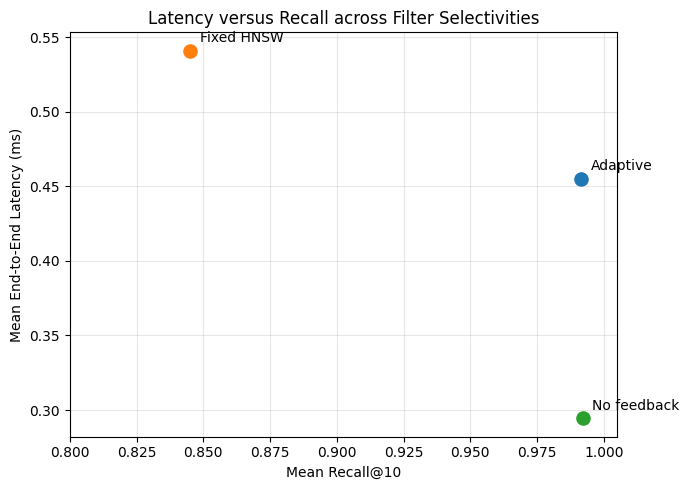

In [75]:
plt.figure(figsize=(7, 5))

for _, row in pooled_summary.iterrows():
    plt.scatter(
        row["mean_recall"],
        row["mean_latency_ms"],
        s=90
    )

    plt.annotate(
        row["policy"],
        (
            row["mean_recall"],
            row["mean_latency_ms"]
        ),
        xytext=(7, 6),
        textcoords="offset points"
    )

plt.xlabel("Mean Recall@10")
plt.ylabel("Mean End-to-End Latency (ms)")
plt.title(
    "Latency versus Recall across Filter Selectivities"
)

plt.grid(True, alpha=0.3)
plt.xlim(0.80, 1.005)

plt.tight_layout()

plt.savefig(
    "figure3_latency_vs_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

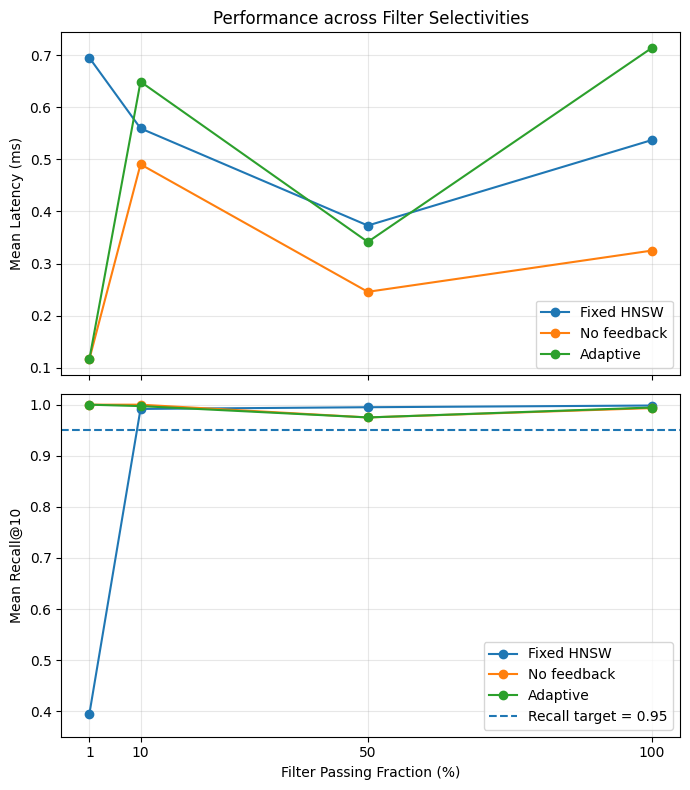

In [76]:
policy_order = [
    "Fixed HNSW",
    "No feedback",
    "Adaptive"
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(7, 8),
    sharex=True
)

for policy in policy_order:

    subset = (
        final_summary_v3[
            final_summary_v3["policy"] == policy
        ]
        .sort_values("selectivity")
    )

    x = subset["selectivity"] * 100

    axes[0].plot(
        x,
        subset["mean_latency_ms"],
        marker="o",
        label=policy
    )

    axes[1].plot(
        x,
        subset["mean_recall"],
        marker="o",
        label=policy
    )


axes[0].set_ylabel("Mean Latency (ms)")
axes[0].set_title(
    "Performance across Filter Selectivities"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()


axes[1].axhline(
    y=0.95,
    linestyle="--",
    label="Recall target = 0.95"
)

axes[1].set_xlabel(
    "Filter Passing Fraction (%)"
)
axes[1].set_ylabel("Mean Recall@10")
axes[1].set_xticks([1, 10, 50, 100])
axes[1].set_ylim(0.35, 1.02)
axes[1].grid(True, alpha=0.3)
axes[1].legend()


plt.tight_layout()

plt.savefig(
    "figure4_selectivity_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
table2 = final_summary_v3.copy()

table2["Passing"] = (
    table2["selectivity"] * 100
).astype(int).astype(str) + "%"

table2 = table2[
    [
        "Passing",
        "policy",
        "mean_recall",
        "mean_latency_ms",
        "p50_latency_ms",
        "p95_latency_ms"
    ]
]

table2.columns = [
    "Passing",
    "Policy",
    "Recall",
    "Mean ms",
    "p50 ms",
    "p95 ms"
]

table2[
    ["Recall", "Mean ms", "p50 ms", "p95 ms"]
] = table2[
    ["Recall", "Mean ms", "p50 ms", "p95 ms"]
].round(3)

table2

,Passing,Policy,Recall,Mean ms,p50 ms,p95 ms
0,1%,Adaptive,1.000,0.117,0.085,0.267
1,1%,Fixed HNSW,0.395,0.695,0.293,2.509
2,1%,No feedback,1.000,0.117,0.067,0.141
3,10%,Adaptive,0.997,0.649,0.248,2.462
4,10%,Fixed HNSW,0.992,0.559,0.298,2.498
5,10%,No feedback,1.000,0.490,0.227,2.005
6,50%,Adaptive,0.975,0.341,0.230,1.170
7,50%,Fixed HNSW,0.995,0.373,0.342,0.517
8,50%,No feedback,0.975,0.246,0.212,0.317
9,100%,Adaptive,0.994,0.714,0.273,2.570


In [78]:
table2.to_csv(
    "table2_final.csv",
    index=False
)

pooled_summary.to_csv(
    "pooled_latency_recall.csv",
    index=False
)

adaptive_overhead_v3.to_csv(
    "adaptive_overhead_v3.csv",
    index=False
)

print("Final report outputs saved.")

Final report outputs saved.


In [79]:
import os

print("Current directory:", os.getcwd())
print("\nFiles:")
for f in os.listdir():
    print(f)

Current directory: /content

Files:
.config
figure3_latency_vs_recall.png
adaptive_overhead_v3.csv
test_results.csv
plan_counts_v2.csv
table2_final.csv
adaptive_overhead_v2.csv
final_summary_v2.csv
audit_event_summary_v2.csv
final_test_records_v2.csv
pooled_latency_recall.csv
final_summary.csv
calibration_records.csv
calibration_summary.csv
figure4_selectivity_performance.png
sample_data


In [80]:
print("final_test_v3 shape:", final_test_v3.shape)
print("final_summary_v3 shape:", final_summary_v3.shape)
print("adaptive_overhead_v3 shape:", adaptive_overhead_v3.shape)

final_test_v3 shape: (2160, 14)
final_summary_v3 shape: (12, 7)
adaptive_overhead_v3 shape: (4, 7)


In [81]:
final_test_v3.to_csv(
    "final_test_records_v3.csv",
    index=False
)

final_summary_v3.to_csv(
    "final_summary_v3.csv",
    index=False
)

adaptive_overhead_v3.to_csv(
    "adaptive_overhead_v3.csv",
    index=False
)

print("V3 files saved:")
print("- final_test_records_v3.csv")
print("- final_summary_v3.csv")
print("- adaptive_overhead_v3.csv")

V3 files saved:
- final_test_records_v3.csv
- final_summary_v3.csv
- adaptive_overhead_v3.csv
